In [132]:
import json
import os
import cv2
import shutil
from pycocotools.coco import COCO
import numpy as np
# import skimage.io as io
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import pylab
import pycocotools.mask as mask_util
matplotlib.use('TkAgg')
pylab.rcParams['figure.figsize'] = (8.0, 10.0)
%matplotlib inline

In [2]:
file = 'F:/Downloads/coco-rem/instances_valrem.json'

In [4]:
coco = COCO(file)

loading annotations into memory...
Done (t=0.92s)
creating index...
index created!


In [5]:
# display COCO categories and supercategories
cats = coco.loadCats(coco.getCatIds())
nms=[cat['name'] for cat in cats]
print('COCO categories: \n{}\n'.format(' '.join(nms)))

nms = set([cat['supercategory'] for cat in cats])
print('COCO supercategories: \n{}'.format(' '.join(nms)))

COCO categories: 
person bicycle car motorcycle airplane bus train truck boat traffic light fire hydrant stop sign parking meter bench bird cat dog horse sheep cow elephant bear zebra giraffe backpack umbrella handbag tie suitcase frisbee skis snowboard sports ball kite baseball bat baseball glove skateboard surfboard tennis racket bottle wine glass cup fork knife spoon bowl banana apple sandwich orange broccoli carrot hot dog pizza donut cake chair couch potted plant bed dining table toilet tv laptop mouse remote keyboard cell phone microwave oven toaster sink refrigerator book clock vase scissors teddy bear hair drier toothbrush

COCO supercategories: 
animal furniture indoor outdoor food person accessory electronic vehicle kitchen appliance sports


In [142]:
cats = ['bench', 'handbag', 'cell phone', 'clock', 'bowl', 'tv']
cat_ids = coco.getCatIds(catNms=cats)
img_ids = []
# cats = coco.loadCats(coco.getCatIds())
# for cat in [cat['name'] for cat in cats]:
for cat in cats:
    _img_ids = coco.getImgIds(catIds=coco.getCatIds(catNms=cat))
    cnt = len(_img_ids)
    print(cat, cnt)
    # if cnt > 200:
        # print(cat, cnt)
    img_ids.extend(_img_ids)
img_ids = set(img_ids)
print('image cnt', len(img_ids))

bench 246
handbag 292
cell phone 218
clock 216
bowl 324
tv 206
image cnt 1286


In [120]:
def new_labelme_json():
    return {
         "flags": {},
        "imageData": None,
        "imageHeight": 0,
        "imagePath": "",
        "imageWidth": 0,
        "shapes": [],
        "version": "5.0.0"
    }

def new_segment_shape():
    return {
        "flags": {},
        "group_id": None,
        "label": "", # person
        "points": [], # [[x1, y1], [x2, y2]...]
        "shape_type": "polygon"
    }

def new_bbox_shape():
    return {
        "flags": {},
        "group_id": None,
        "label": "", # person
        "points": [], # [[x1, y1], [x2, y2]]
        "shape_type": "rectangle"
    }

def binarize_mask(mask_or_polygons, height: int, width: int):
    """
    Convert input masks of any format to a binary mask (np.uint8 array with 1
    as foreground and 0 as background).
    """
    m = mask_or_polygons
    if isinstance(m, dict):
        # RLEs
        assert "counts" in m and "size" in m
        if isinstance(m["counts"], list):  # uncompressed RLEs
            h, w = m["size"]
            assert h == height and w == width
            m = mask_util.frPyObjects(m, h, w)
        mask = mask_util.decode(m)[:, :]

    if isinstance(m, list):  # list[ndarray]
        m = mask_util.frPyObjects(m, height, width)
        m = mask_util.merge(m)
        mask = mask_util.decode(m)[:, :]

    if isinstance(m, np.ndarray):  # assumed to be a binary mask
        assert m.shape[1] != 2, m.shape
        assert m.shape == (
            height,
            width,
        ), f"mask shape: {m.shape}, target dims: {height}, {width}"
        mask = m.astype("uint8")

    return mask

In [121]:
coco.loadImgs([377368])

[{'license': 4,
  'file_name': '000000377368.jpg',
  'coco_url': 'http://images.cocodataset.org/val2017/000000377368.jpg',
  'height': 481,
  'width': 640,
  'date_captured': '2013-11-18 11:22:55',
  'flickr_url': 'http://farm6.staticflickr.com/5293/5538913095_e3c5a908bc_z.jpg',
  'id': 377368}]

In [145]:
data_dir = 'F:/data/VOC/val2017'
out_dir = 'F:/data/fusion'
images_dir = 'F:/data/fusion/images'
jsons_dir = 'F:/data/fusion/jsons'
for img_id in img_ids:
    img = coco.loadImgs(img_id)[0]
    height, width = img['height'], img['width']
    fname = img['file_name']
    print(fname)
    fpath = os.path.join(data_dir, fname).replace('\\', '/')
    annIds = coco.getAnnIds(imgIds=img_id, catIds=cat_ids, iscrowd=None)
    dst_img_path = os.path.join(images_dir, fname).replace('\\', '/')
    # shutil.copy(fpath, dst_img_path)
    anns = coco.loadAnns(annIds)
    json_path = os.path.join(jsons_dir, fname.split('.')[0] + '.json').replace('\\', '/')
    obj = new_labelme_json()
    for ann in anns:
        area = ann['area']
        if area < 4:
            continue
        cat_id = ann['category_id']
        cat = coco.loadCats(cat_id)[0]
        label = cat['name']
        label = label.replace(' ', '_')
        rect_shape = new_bbox_shape()
        rect_shape['label'] = label
        x,y,w,h = ann['bbox']
        points = [[x, y], [x+w, y+h]]
        rect_shape['points'] = points
        obj['shapes'].append(rect_shape)
        mask = binarize_mask(ann['segmentation'], height, width)
        contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) > 0:
            area = cv2.contourArea(contours[0])
            if area >= 4:
                segment_shape = new_segment_shape()
                segment_shape['label'] = label
                segment_shape['points'] = np.squeeze(contours[0]).tolist()
                obj['shapes'].append(segment_shape)
        with open(json_path, 'w') as f:
            json.dump(obj, f)
    
    

000000385029.jpg
000000458768.jpg
000000376856.jpg
000000434204.jpg
000000401446.jpg
000000466986.jpg
000000213035.jpg
000000368684.jpg
000000434230.jpg
000000131131.jpg
000000254016.jpg
000000131138.jpg
000000016451.jpg
000000106563.jpg
000000122962.jpg
000000335954.jpg
000000262227.jpg
000000008277.jpg
000000442456.jpg
000000098392.jpg
000000368752.jpg
000000032887.jpg
000000450686.jpg
000000000139.jpg
000000180383.jpg
000000524456.jpg
000000286908.jpg
000000114884.jpg
000000319696.jpg
000000327890.jpg
000000016598.jpg
000000426203.jpg
000000278749.jpg
000000565469.jpg
000000295138.jpg
000000467176.jpg
000000458992.jpg
000000057597.jpg
000000426241.jpg
000000368900.jpg
000000147729.jpg
000000532761.jpg
000000229659.jpg
000000147740.jpg
000000540962.jpg
000000221502.jpg
000000074058.jpg
000000123213.jpg
000000033104.jpg
000000336209.jpg
000000426329.jpg
000000549220.jpg
000000131431.jpg
000000352618.jpg
000000057725.jpg
000000369037.jpg
000000459153.jpg
000000377239.jpg
000000098716.j

In [94]:
anns[0].keys()

dict_keys(['segmentation', 'area', 'iscrowd', 'image_id', 'bbox', 'category_id', 'id', 'source', 'source_id'])

{'size': [481, 640],
 'counts': [203981,
  7,
  470,
  14,
  464,
  20,
  455,
  36,
  440,
  55,
  422,
  64,
  413,
  69,
  410,
  72,
  407,
  75,
  404,
  77,
  402,
  80,
  399,
  83,
  397,
  84,
  397,
  85,
  396,
  85,
  396,
  86,
  395,
  86,
  395,
  87,
  394,
  88,
  393,
  88,
  393,
  89,
  392,
  90,
  391,
  90,
  391,
  91,
  390,
  91,
  390,
  92,
  389,
  93,
  388,
  93,
  388,
  93,
  388,
  94,
  387,
  94,
  387,
  94,
  387,
  94,
  387,
  93,
  388,
  93,
  388,
  93,
  388,
  92,
  389,
  92,
  389,
  91,
  390,
  91,
  390,
  91,
  390,
  90,
  391,
  90,
  391,
  90,
  391,
  89,
  392,
  89,
  392,
  89,
  392,
  88,
  393,
  88,
  393,
  87,
  394,
  87,
  394,
  87,
  394,
  86,
  395,
  86,
  395,
  85,
  396,
  85,
  396,
  84,
  397,
  84,
  397,
  83,
  398,
  83,
  398,
  83,
  398,
  82,
  399,
  82,
  399,
  82,
  399,
  81,
  400,
  81,
  400,
  81,
  400,
  80,
  401,
  80,
  401,
  80,
  401,
  79,
  402,
  79,
  402,
  78,
  403,
  78,
  403

In [104]:
# get all images containing given categories, select one at random
catIds = coco.getCatIds(catNms=['person'])
imgIds = coco.getImgIds(catIds=catIds )
# imgIds = coco.getImgIds(imgIds = [377368])


{'size': [640, 457], 'counts': [51091, 1, 639, 3, 636, 6, 633, 8, 631, 10, 629, 12, 626, 16, 623, 20, 618, 28, 3, 1, 5, 8, 594, 49, 581, 61, 575, 66, 571, 70, 565, 75, 563, 77, 560, 80, 370, 19, 169, 82, 367, 27, 163, 83, 364, 34, 156, 87, 361, 37, 153, 89, 358, 41, 151, 90, 355, 45, 148, 92, 353, 48, 145, 94, 349, 53, 142, 96, 346, 71, 125, 98, 343, 76, 122, 99, 340, 83, 116, 101, 337, 88, 113, 102, 332, 95, 109, 104, 328, 101, 106, 105, 324, 106, 103, 107, 321, 109, 102, 108, 316, 115, 99, 111, 310, 120, 98, 112, 306, 124, 96, 114, 303, 128, 94, 115, 300, 131, 93, 116, 297, 135, 91, 117, 294, 138, 90, 118, 291, 142, 87, 120, 289, 144, 86, 121, 287, 147, 84, 122, 286, 149, 83, 122, 283, 152, 81, 124, 281, 154, 81, 123, 280, 156, 80, 124, 278, 158, 78, 126, 277, 112, 2, 45, 77, 126, 276, 113, 5, 6, 3, 33, 77, 127, 274, 114, 19, 27, 77, 97, 7, 25, 273, 114, 23, 22, 77, 95, 15, 20, 272, 115, 32, 8, 82, 94, 21, 14, 273, 115, 121, 90, 31, 8, 274, 115, 120, 92, 311, 115, 96, 18, 6, 94, 310,

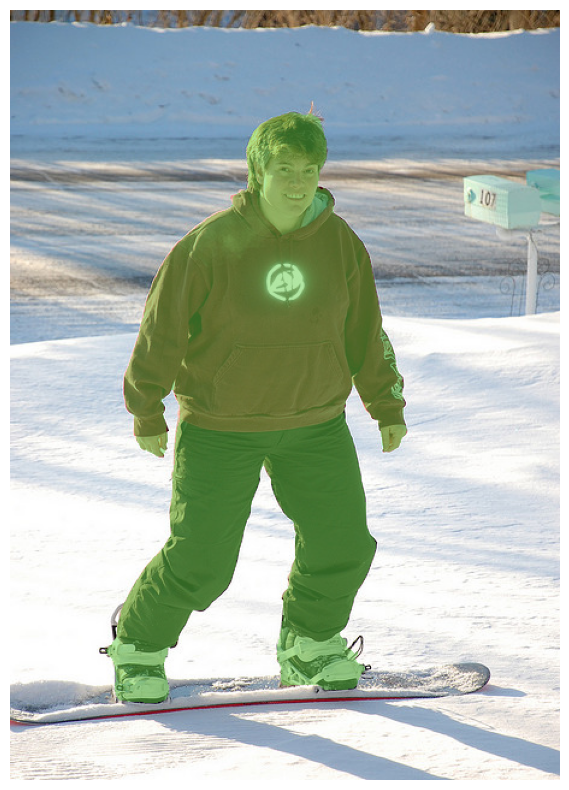

In [107]:
img = coco.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]
# load and display image
image = Image.open(f"F:/data/VOC/val2017/{img['file_name']}")
# load and display instance annotations
plt.imshow(image); plt.axis('off')
annIds = coco.getAnnIds(imgIds=img['id'], catIds=catIds, iscrowd=None)
anns = coco.loadAnns(annIds)
print(anns[0]['segmentation'])
coco.showAnns(anns)

In [114]:
seg = anns[0]['segmentation']
h,w = seg['size']
m = mask_util.frPyObjects(seg, h, w)
mask = mask_util.decode(m)
mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [117]:
contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [131]:
np.squeeze(contours[0]).shape

(856, 2)

In [3]:
obj['annotations'][0]

NameError: name 'obj' is not defined